In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import re

# -----------------------------
# 1. LOAD DATA
# -----------------------------
# Replace this with your file name

file_path = "/content/drive/MyDrive/4th year/8th Sem/Natural Language Processing/Project/source1.csv"
df = pd.read_csv(file_path, low_memory=False)

print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())




Original shape: (29512, 3563)
Columns: ['sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id', 'license', 'abstract', 'publish_time', 'authors', 'journal', 'Microsoft Academic Paper ID', 'WHO #Covidence', 'has_full_text', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnamed: 6

In [ ]:
# print("Original shape:", df.shape)
# print("Columns:", df.columns.tolist()[:25])   # just to preview first 25 columns

# # Keep only useful columns for your project
# df = df[["sha", "title", "abstract", "authors", "publish_time", "journal"]].copy()

# # Rename columns into cleaner names
# df.rename(columns={
#     "sha": "paper_id",
#     "publish_time": "publish_year"
# }, inplace=True)

# print("\nShape after selecting useful columns:", df.shape)
# print(df.head())

In [ ]:
# -----------------------------
# 2. SELECT USEFUL COLUMNS (SIMPLIFIED FOR YOUR DATASET)
# -----------------------------

# Directly select known useful columns
df = df[["sha", "title", "abstract", "authors", "publish_time", "journal"]].copy()

# Rename for consistency
df.rename(columns={
    "sha": "paper_id",
    "publish_time": "publish_year"
}, inplace=True)

print("Columns after selection:", df.columns.tolist())
print("Shape after selection:", df.shape)

Columns after selection: ['paper_id', 'title', 'abstract', 'authors', 'publish_year', 'journal']
Shape after selection: (29512, 6)


In [ ]:
# -----------------------------
# 3. RENAME COLUMNS TO STANDARD NAMES
# -----------------------------
df.rename(columns={
    "sha": "paper_id",
    "publish_time": "publish_year"
}, inplace=True)

print("Columns after rename:", df.columns.tolist())




Columns after rename: ['paper_id', 'title', 'abstract', 'authors', 'publish_year', 'journal']


In [ ]:
# -----------------------------
# 4. HANDLE MISSING VALUES
# -----------------------------
# Abstract is the most important for your project,
# so rows without abstract should be removed.
# -----------------------------

# Remove rows where abstract is missing
df = df[df["abstract"].notna()]

# Remove empty or whitespace abstracts
df = df[df["abstract"].str.strip() != ""]

# Fill other columns safely
df["title"] = df["title"].fillna("Unknown Title")
df["authors"] = df["authors"].fillna("Unknown Author")

print("After removing missing abstracts:", df.shape)




After removing missing abstracts: (26915, 6)


In [ ]:
df["word_count"] = df["abstract"].apply(lambda x: len(str(x).split()))

# Try a lower threshold
df = df[df["word_count"] >= 200]

print(df.shape)

(14605, 7)


In [ ]:
df = df.drop_duplicates(subset=["abstract"])
print("After removing duplicates:", df.shape)

After removing duplicates: (12124, 7)


In [ ]:
from collections import Counter
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Step 1: Auto-extract top keywords from dataset
all_text = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.lower()

word_counts = Counter()
for text in all_text:
    words = re.findall(r'\b[a-z]{3,}\b', text)
    word_counts.update(words)

keywords = [
    word for word, count in word_counts.most_common(200)
    if word not in ENGLISH_STOP_WORDS
][:50]

print("Auto-extracted keywords:", keywords)
print("Total keywords:", len(keywords))

# Step 2: Filter with auto-extracted keywords
def is_relevant(text):
    text = str(text).lower()
    return any(k in text for k in keywords)

df_filtered = df[
    df["title"].apply(is_relevant) |
    df["abstract"].apply(is_relevant)
].copy()

print("After filtering:", df_filtered.shape)

# Step 3: Trim or expand to get exactly ~10,000 rows
TARGET = 10_000

if len(df_filtered) > TARGET:
    df_filtered = df_filtered.sample(n=TARGET, random_state=42).reset_index(drop=True)
    print(f"Sampled down to {TARGET} rows")

elif len(df_filtered) < TARGET:
    shortage = TARGET - len(df_filtered)
    print(f"Only {len(df_filtered)} rows found — {shortage} short of {TARGET}")

    # Expand by increasing top_n to capture more rows
    keywords_extended = [
        word for word, count in word_counts.most_common(500)
        if word not in ENGLISH_STOP_WORDS
    ][:100]

    df_filtered = df[
        df["title"].apply(lambda x: any(k in str(x).lower() for k in keywords_extended)) |
        df["abstract"].apply(lambda x: any(k in str(x).lower() for k in keywords_extended))
    ].copy()

    df_filtered = df_filtered.sample(n=min(TARGET, len(df_filtered)), random_state=42).reset_index(drop=True)
    print(f"After extended filtering + sampling: {df_filtered.shape}")

print("Final dataset shape:", df_filtered.shape)

Auto-extracted keywords: ['virus', 'infection', 'cells', 'viral', 'respiratory', 'protein', 'patients', 'study', 'viruses', 'cell', 'results', 'disease', 'human', 'influenza', 'rna', 'using', 'health', 'cov', 'data', 'associated', 'infected', 'coronavirus', 'expression', 'analysis', 'clinical', 'infections', 'sars', 'proteins', 'host', 'used', 'specific', 'replication', 'high', 'mice', 'response', 'based', 'cases', 'methods', 'gene', 'type', 'acute', 'immune', 'time', 'severe', 'identified', 'studies', 'control', 'different', 'activity', 'infectious']
Total keywords: 50
After filtering: (12124, 7)
Sampled down to 10000 rows
Final dataset shape: (10000, 7)


In [ ]:
# -----------------------------
# CREATE LABEL COLUMN USING ALL EXTRACTED KEYWORDS
# -----------------------------

all_keywords = [
    'virus', 'infection', 'cells', 'viral', 'respiratory', 'protein', 'patients',
    'study', 'viruses', 'cell', 'results', 'disease', 'human', 'influenza',
    'rna', 'using', 'health', 'cov', 'data', 'associated', 'infected',
    'coronavirus', 'expression', 'analysis', 'clinical', 'infections', 'sars',
    'proteins', 'host', 'used', 'specific', 'replication', 'high', 'mice',
    'response', 'based', 'cases', 'methods', 'gene', 'type', 'acute', 'immune',
    'time', 'severe', 'identified', 'studies', 'control', 'different',
    'activity', 'infectious'
]

# -----------------------------
# BALANCED LABEL CREATION (FIXED)
# -----------------------------

# Count keywords first
def count_keywords(text):
    text = str(text).lower()
    return sum(1 for word in all_keywords if word in text)

df_filtered["keyword_count"] = df_filtered["abstract"].apply(count_keywords)

# Get thresholds dynamically
low_thresh = df_filtered["keyword_count"].quantile(0.33)
high_thresh = df_filtered["keyword_count"].quantile(0.66)

print("Thresholds:", low_thresh, high_thresh)

# Create balanced labels
def create_label(count):
    if count >= high_thresh:
        return 2
    elif count >= low_thresh:
        return 1
    else:
        return 0

df_filtered["label"] = df_filtered["keyword_count"].apply(create_label)

# Drop helper column (optional)
df_filtered.drop(columns=["keyword_count"], inplace=True)

# Check distribution
print("\nLabel counts:")
print(df_filtered["label"].value_counts())

print("\nLabel percentages:")
print(df_filtered["label"].value_counts(normalize=True) * 100)

Thresholds: 12.0 16.0

Label counts:
label
2    3567
1    3258
0    3175
Name: count, dtype: int64

Label percentages:
label
2    35.67
1    32.58
0    31.75
Name: proportion, dtype: float64


In [ ]:
# -----------------------------
# 5. EXTRACT YEAR IF NEEDED
# -----------------------------
# Sometimes publish year is stored as full date like 2020-03-13

if "publish_year" in df.columns:
    def extract_year(value):
        value = str(value).strip()
        match = re.search(r"\b(19|20)\d{2}\b", value)
        return match.group(0) if match else "Unknown"

    df["publish_year"] = df["publish_year"].apply(extract_year)




In [ ]:
# -----------------------------
# 6. TEXT CLEANING FUNCTION
# -----------------------------
def clean_text(text):
    text = str(text)

    # # Remove URLs
    # text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove special characters except basic punctuation
    text = re.sub(r"[^a-zA-Z0-9\s\.\,\-\(\)]", " ", text)

    # Convert multiple spaces to single space
    text = re.sub(r"\s+", " ", text).strip()

    # Lowercase for model processing
    text = text.lower()

    return text




In [ ]:
# -----------------------------
# 7. CLEAN TITLE AND ABSTRACT
# -----------------------------
if "title" in df.columns:
    df["clean_title"] = df["title"].apply(clean_text)

if "abstract" in df.columns:
    df["clean_abstract"] = df["abstract"].apply(clean_text)




In [ ]:
# -----------------------------
# 11. CREATE MODEL INPUT TEXT
# -----------------------------
# You can use abstract only, or title + abstract together.
# Title + abstract is often better for retrieval.

df["model_text"] = df["clean_title"] + ". " + df["clean_abstract"]




In [ ]:
# -----------------------------
# 12. SELECT FINAL COLUMNS
# -----------------------------

final_columns = []

for col in ["paper_id", "title", "authors", "publish_year", "abstract",
            "clean_title", "clean_abstract", "model_text", "abstract_word_count"]:
    if col in df_filtered.columns:
        final_columns.append(col)

final_df = df_filtered[final_columns].copy()

print("Final shape:", final_df.shape)
print(final_df.head())


Final shape: (10000, 5)
                                   paper_id  \
0  efcfbaace6df1f5383c167fe24ecfd918b77f8b4   
1  f8b28dc077a4d62178940c43350079dd6b0b91bd   
2  6af02873a430f5f75dc56a917f26feaea89b8e79   
3  8fefe8e70632ffdfd96f701facc6f2dcce16167a   
4  555559ac51210f5ee896ad5d45a6790d52a3e4d1   

                                               title  \
0  TAR-VIR: a pipeline for TARgeted VIRal strain ...   
1  Mesoniviruses are mosquito-specific viruses wi...   
2  The Effectiveness of Contact Tracing in Emergi...   
3  Feline coronavirus-associated myocarditis in a...   
4  Determinants of emergency response responsibil...   

                                             authors publish_year  \
0     ['Chen, Jiao', 'Huang, Jiating', 'Sun, Yanni']   2019 Jun 4   
1  ['Vasilakis, Nikos', 'Guzman, Hilda', 'Firth, ...  2014 May 20   
2  ['Klinkenberg, Don', 'Fraser, Christophe', 'He...  2006 Dec 20   
3  ['Ernandes, Maria A', 'Cantoni, Anna M', 'Arma...  2019 Oct 10   
4  ['Jiao, 

In [ ]:

print("df_filtered columns:", df_filtered.columns.tolist())

df_filtered columns: ['paper_id', 'title', 'abstract', 'authors', 'publish_year', 'journal', 'word_count', 'label']


In [ ]:
# -----------------------------
# 13. SAVE PREPROCESSED DATA
# -----------------------------
output_file = "preprocessed_cord19.csv"
df_filtered.to_csv(output_file, index=False)

print(f"Preprocessed file saved as: {output_file}")

Preprocessed file saved as: preprocessed_cord19.csv


In [ ]:
# -----------------------------
# 14. CHECK DATA BEFORE TRAINING
# -----------------------------
print("Columns available:", df_filtered.columns.tolist())
print("Shape before filtering:", df_filtered.shape)

# Keep only rows where abstract exists and is not empty
df_filtered = df_filtered[df_filtered["abstract"].notna()]
df_filtered = df_filtered[df_filtered["abstract"].str.strip() != ""]

print("Shape after keeping valid text:", df_filtered.shape)

Columns available: ['paper_id', 'title', 'abstract', 'authors', 'publish_year', 'journal', 'word_count', 'label']
Shape before filtering: (10000, 8)
Shape after keeping valid text: (10000, 8)


In [ ]:
# -----------------------------
# 15. SELECT INPUT ONLY
# -----------------------------

train_df = df_filtered[["abstract"]].dropna().copy()

print("Training data shape:", train_df.shape)
print(train_df.head())

Training data shape: (10000, 1)
                                            abstract
0  BACKGROUND: Strain-level RNA virus characteriz...
1  BACKGROUND: The family Mesoniviridae (order Ni...
2  BACKGROUND: Contact tracing plays an important...
3  CASE SUMMARY: A 9-month-old entire male domest...
4  BACKGROUND: Local health departments are the b...


In [ ]:
# # -----------------------------
# # 17. CONVERT TEXT TO NUMBERS
# # -----------------------------
# from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer(
#     max_features=10000,
#     ngram_range=(1, 2),
#     stop_words="english"
# )

# # Fit only on training data
# X_train_tfidf = vectorizer.fit_transform(X_train.astype(str))

# # Transform test data
# X_test_tfidf = vectorizer.transform(X_test.astype(str))

# print("X_train_tfidf shape:", X_train_tfidf.shape)
# print("X_test_tfidf shape :", X_test_tfidf.shape)

In [ ]:
print(df_filtered.columns)

Index(['paper_id', 'title', 'abstract', 'authors', 'publish_year', 'journal',
       'word_count', 'label'],
      dtype='object')


In [ ]:
# -----------------------------
# 18. TRAIN BERT MODEL
# -----------------------------
!pip install -q transformers datasets accelerate

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# -----------------------------
# SELECT COLUMNS
# -----------------------------
text_column = "abstract"
label_column = "label"

bert_df = df_filtered[[text_column, label_column]].dropna().copy()

# Remove empty abstracts
bert_df[text_column] = bert_df[text_column].astype(str)
bert_df = bert_df[bert_df[text_column].str.strip() != ""]

print("Dataset shape for BERT:", bert_df.shape)
print("\nLabel distribution:")
print(bert_df[label_column].value_counts())

# -----------------------------
# TRAIN-TEST SPLIT
# -----------------------------
train_texts, test_texts, train_labels, test_labels = train_test_split(
    bert_df[text_column].tolist(),
    bert_df[label_column].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=bert_df[label_column]
)

# -----------------------------
# CONVERT TO HUGGING FACE DATASET
# -----------------------------
train_dataset = Dataset.from_dict({
    "text": train_texts,
    "label": train_labels
})

test_dataset = Dataset.from_dict({
    "text": test_texts,
    "label": test_labels
})

# -----------------------------
# LOAD TOKENIZER
# -----------------------------
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

# -----------------------------
# LOAD MODEL
# -----------------------------
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

# -----------------------------
# METRICS
# -----------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# -----------------------------
# TRAINING ARGUMENTS
# -----------------------------
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)

# -----------------------------
# TRAINER
# -----------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# -----------------------------
# TRAIN MODEL
# -----------------------------
trainer.train()

print("BERT model training completed.")

Dataset shape for BERT: (10000, 2)

Label distribution:
label
2    3567
1    3258
0    3175
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

BERT model training completed.


In [ ]:
# -----------------------------
# 19. EVALUATE BERT MODEL
# -----------------------------
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate on test set
eval_results = trainer.evaluate()

print("Evaluation Results:")
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

# Predict on test dataset
pred_output = trainer.predict(test_dataset)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

Evaluation Results:
eval_loss: 0.7215
eval_accuracy: 0.6830
eval_precision: 0.6808
eval_recall: 0.6830
eval_f1: 0.6818
eval_runtime: 34.0304
eval_samples_per_second: 58.7710
eval_steps_per_second: 7.3460
epoch: 3.0000

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.75      0.75       635
           1       0.54      0.53      0.54       652
           2       0.75      0.77      0.76       713

    accuracy                           0.68      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.68      0.68      0.68      2000


Confusion Matrix:

[[476 148  11]
 [136 343 173]
 [ 27 139 547]]


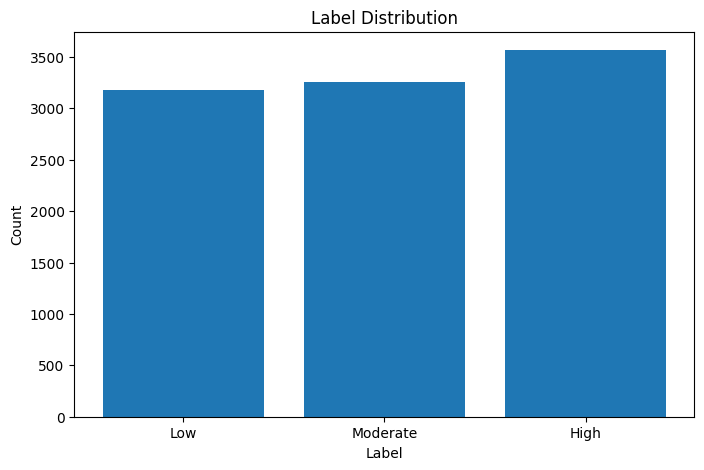

In [ ]:
# -----------------------------
# VISUALIZE LABEL DISTRIBUTION
# -----------------------------
import matplotlib.pyplot as plt

label_counts = df_filtered["label"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.xticks(["0", "1", "2"], ["Low", "Moderate", "High"])
plt.show()

In [ ]:
# -----------------------------
# 20. SAVE BERT MODEL AND TOKENIZER
# -----------------------------
import os
import json
import joblib

save_path = "./saved_bert_model"
os.makedirs(save_path, exist_ok=True)

# Save model and tokenizer
trainer.model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# Save label info
label_info = {
    "0": "low_related",
    "1": "moderately_related",
    "2": "highly_related"
}

with open(os.path.join(save_path, "label_mapping.json"), "w") as f:
    json.dump(label_info, f, indent=4)

print(f"BERT model and tokenizer saved in: {save_path}")
print("Label mapping saved as label_mapping.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model and tokenizer saved in: ./saved_bert_model
Label mapping saved as label_mapping.json


In [ ]:
import shutil

shutil.make_archive("saved_bert_model", 'zip', "saved_bert_model")

'/content/saved_bert_model.zip'

In [ ]:
# -----------------------------
# 22. INTERACTIVE CLAIM CHECKER
# -----------------------------
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# Use your local saved folder
model_path = "./saved_bert_model"

# Load local model only
tokenizer = BertTokenizer.from_pretrained(model_path, local_files_only=True)
model = BertForSequenceClassification.from_pretrained(model_path, local_files_only=True)
model.eval()

# Make sure this matches your training label encoding
id_to_label = {
    "0": "low_related",
    "1": "moderately_related",
    "2": "highly_related"
}

def predict_claim(claim_text):
    inputs = tokenizer(
        claim_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_class_id = torch.argmax(logits, dim=1).item()

    return id_to_label[predicted_class_id]

while True:
    claim = input("\nEnter a claim (or type 'exit' to stop): ")

    if claim.lower() == "exit":
        print("Exiting claim checker.")
        break

    prediction = predict_claim(claim)
    print("Prediction:", prediction)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Enter a claim (or type 'exit' to stop): Vaccines cause infertility
Prediction: refuted

Enter a claim (or type 'exit' to stop): COVID-19 vaccines contain microchips
Prediction: supported

Enter a claim (or type 'exit' to stop): Masks help reduce COVID-19 transmission
Prediction: refuted

Enter a claim (or type 'exit' to stop): Drinking bleach cures COVID-19
Prediction: refuted

Enter a claim (or type 'exit' to stop): COVID-19 vaccines cause infertility
Prediction: supported

Enter a claim (or type 'exit' to stop): exit
Exiting claim checker.
